In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

import joblib

In [2]:
df = pd.read_csv(
    "../data/raw/accepted_2007_to_2018Q4.csv.gz",
    compression="gzip",
    low_memory=False
)

df = df[
    df["loan_status"].isin(
        [
            "Fully Paid",
            "Charged Off"
        ]
    )
].copy()

df["target"] = (
    df["loan_status"] == "Charged Off"
).astype(int)

In [3]:
FEATURES = [
    "revol_util",
    "bc_util",
    "home_ownership",
    "purpose",
    "verification_status"
]

In [4]:
df_model = df[
    FEATURES + ["target"]
].copy()

In [5]:
for col in [

    "revol_util",

    "bc_util"

]:

    df_model[col] = (
        df_model[col]
        .fillna(
            df_model[col].median()
        )
    )

for col in [

    "home_ownership",

    "purpose",

    "verification_status"

]:

    df_model[col] = (
        df_model[col]
        .fillna("Unknown")
        .astype(str)
    )

In [6]:
home_default_rate = (
    df.groupby("home_ownership")["target"]
    .mean()
)

housing_map = {}

for key, value in home_default_rate.items():

    housing_map[key] = 100 - value * 100

In [7]:
purpose_default_rate = (
    df.groupby("purpose")["target"]
    .mean()
)

purpose_map = {}

for key, value in purpose_default_rate.items():

    purpose_map[key] = 100 - value * 100

In [8]:
verification_default_rate = (
    df.groupby("verification_status")["target"]
    .mean()
)

verification_map = {}

for key, value in verification_default_rate.items():

    verification_map[key] = 100 - value * 100

In [9]:
df_model["credit_utilization_score"] = (

    100

    -

    np.clip(

        (

            df_model["revol_util"]

            +

            df_model["bc_util"]

        ) / 2,

        0,

        100

    )

)

In [10]:
df_model["housing_stability_score"] = (

    df_model["home_ownership"]

    .map(housing_map)

    .fillna(

        np.mean(

            list(

                housing_map.values()

            )

        )

    )

)

In [11]:
df_model["purpose_risk_score"] = (

    df_model["purpose"]

    .map(purpose_map)

    .fillna(

        np.mean(

            list(

                purpose_map.values()

            )

        )

    )

)

In [12]:
df_model["verification_score"] = (

    df_model["verification_status"]

    .map(

        verification_map

    )

    .fillna(

        np.mean(

            list(

                verification_map.values()

            )

        )

    )

)

In [13]:
FEATURES = [

    "revol_util",

    "bc_util",

    "credit_utilization_score",

    "housing_stability_score",

    "purpose_risk_score",

    "verification_score"

]

In [14]:
X = df_model[FEATURES]

y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [15]:
model = XGBClassifier(

    max_depth=4,

    learning_rate=0.05,

    n_estimators=300,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

model.fit(

    X_train,

    y_train

)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [16]:
prob = model.predict_proba(

    X_test

)[:,1]

In [17]:
thresholds = np.arange(

    0.20,

    0.60,

    0.01

)

best_threshold = 0

best_f1 = 0

for t in thresholds:

    pred = (

        prob >= t

    ).astype(int)

    score = f1_score(

        y_test,

        pred

    )

    if score > best_f1:

        best_f1 = score

        best_threshold = t

print(best_threshold)

print(best_f1)

0.2
0.35095644962407657


In [18]:
pred = (

    prob >= best_threshold

).astype(int)

In [19]:
print("Accuracy :", accuracy_score(y_test,pred))

print("Precision:", precision_score(y_test,pred))

print("Recall   :", recall_score(y_test,pred))

print("F1 Score :", f1_score(y_test,pred))

print("ROC AUC  :", roc_auc_score(y_test,prob))

Accuracy : 0.557878853201121
Precision: 0.24822103882071467
Recall   : 0.5987861185582365
F1 Score : 0.35095644962407657
ROC AUC  : 0.6031155739916433


In [20]:
behavior_index = (

    (1 - prob)

    * 100

)

behavior_index[:10]

array([75.23625 , 88.66668 , 83.338135, 84.7899  , 81.935585, 75.27592 ,
       69.758766, 77.6933  , 87.86644 , 80.18913 ], dtype=float32)

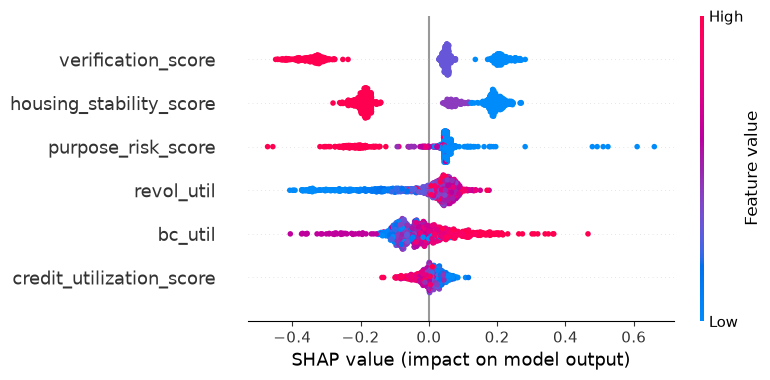

In [21]:
import shap

# Create explainer
explainer = shap.TreeExplainer(model)

# Sample data for visualization
X_sample = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(
    shap_values,
    X_sample
)

In [22]:
shap_importance = pd.DataFrame({

    "feature": FEATURES,

    "impact": np.abs(shap_values).mean(axis=0)

})

shap_importance = shap_importance.sort_values(

    by="impact",

    ascending=False

)

shap_importance

,feature,impact
5,verification_score,0.185598
3,housing_stability_score,0.180044
4,purpose_risk_score,0.092450
0,revol_util,0.080985
1,bc_util,0.074308
2,credit_utilization_score,0.027203


In [23]:
importance = pd.DataFrame({

    "feature":FEATURES,

    "importance":model.feature_importances_

})

importance.sort_values(

    by="importance",

    ascending=False

)

,feature,importance
5,verification_score,0.468621
3,housing_stability_score,0.358794
4,purpose_risk_score,0.064171
1,bc_util,0.044418
0,revol_util,0.032663
2,credit_utilization_score,0.031332


In [24]:
joblib.dump(

    model,

    "../models/behavior_model.pkl"

)

joblib.dump(

    FEATURES,

    "../models/behavior_features.pkl"

)

joblib.dump(

    best_threshold,

    "../models/behavior_threshold.pkl"

)

behavior_maps = {

    "housing":housing_map,

    "purpose":purpose_map,

    "verification":verification_map

}

joblib.dump(

    behavior_maps,

    "../models/behavior_maps.pkl"

)

joblib.dump(

    explainer,

    "../models/behavior_shap_explainer.pkl"

)

['../models/behavior_shap_explainer.pkl']